In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nawaabjaade/data-vcenjsus/Crime_Data_from_2020_to_Present (1).csv


GPU CONFIGURATION
PyTorch : 2.10.0+cu128
CUDA    : True
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Device      : cuda
Multi-GPU   : True
Batch size  : 512

Loading data ...
Raw shape: 815,882 × 28
After column select + dropna: 815,882
Unique classes (raw): 138
After rare-class filter: 136 classes, 815,879 samples

Stratified split ...
Classes dropped (too rare): 8
Classes remaining         : 128
Final label space: contiguous 0 → 127  (128 classes)
Train : 571,086  (70.0%)
Val   : 122,378  (15.0%)
Test  : 122,378  (15.0%)

Building features (no-leakage pipeline) ...
TF-IDF vocab  : 231  (max=500)
Input dim     : 237  (231 TF-IDF + 2 numerical + 4 categorical)
Feature ranges (after fix):
  TF-IDF   : 0.000 – 1.000
  Numerical: -2.042 – 3.179
  Categor. : 0.000 – 1.000
X_train : (571086, 237)
X_val   : (122378, 237)
X_test  : (122378, 237)
Classes : 128
DataParallel across 2 GPUs
Trainable params : 224,090  (~0.22M)
SAS enabled      : False
NUM_CLASSES      : 128
Loss             : CrossEntropyL

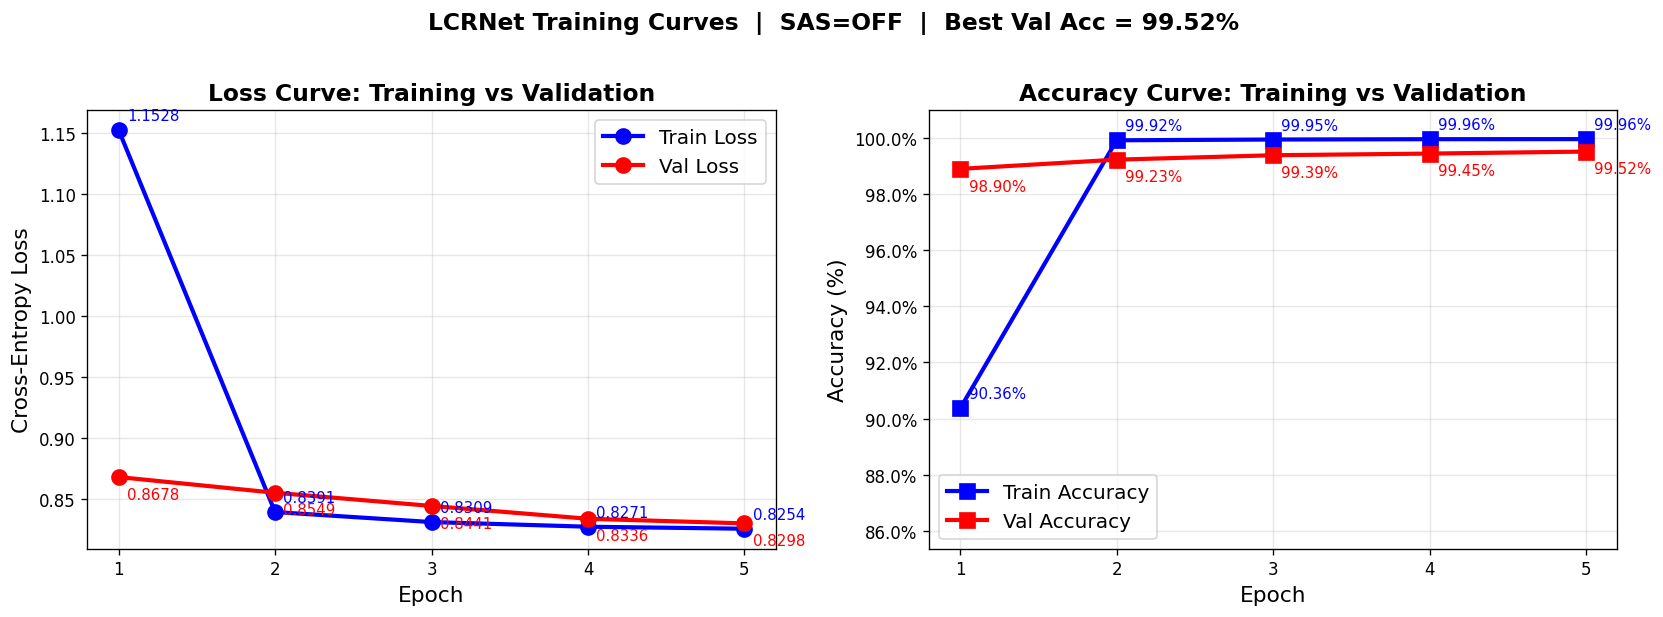

Generalization gap (Train−Val Acc): 0.0044  → well generalised

TEST EVALUATION  (loading best checkpoint)

  Test Accuracy      : 0.9952  (99.52%)
  Weighted Precision : 0.9917
  Weighted Recall    : 0.9952
  Weighted F1        : 0.9932
  Macro F1           : 0.6333  ← key for class-imbalance
  Micro F1           : 0.9952

  Note: Macro F1 is lower than Weighted F1 by design — the dataset
  has extreme class imbalance (128 classes, some with 1-3 samples).
  Weighted F1 is the primary metric for this imbalanced task.

--- Full Per-Class Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       208
           1       0.00      0.00      0.00         1
           2       1.00      1.00      1.00       486
           3       0.61      1.00      0.76        42
           4       1.00      1.00      1.00      4197
           5       1.00      1.00      1.00       638
           6       1.00      1.00      1.00      7048
           7 

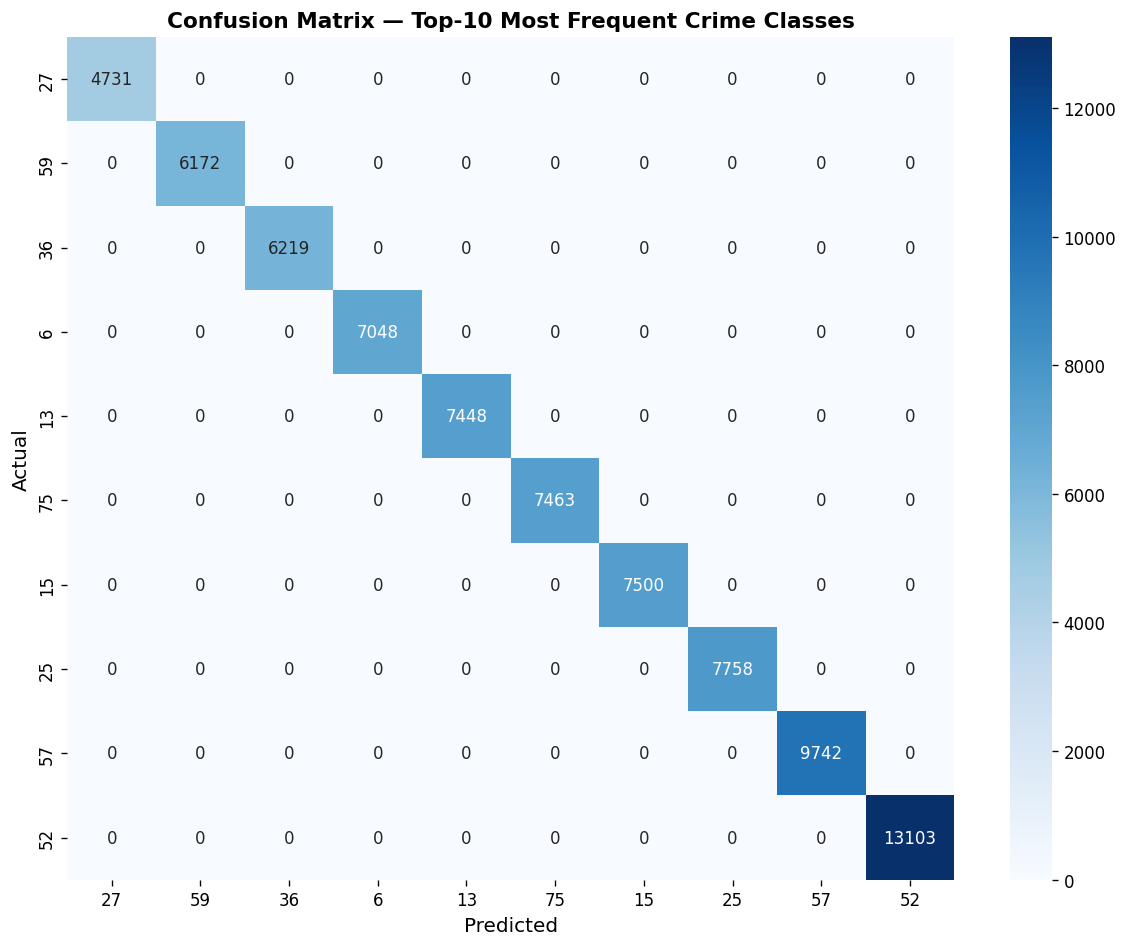


SHAP EXPLAINABILITY ANALYSIS
Background: 100  |  Explain: 100 samples
Running GradientExplainer ...
SHAP tensor: (100, 237, 128)  (N, F, C)

[1/6] Global Feature Importance ...
 Feature  Mean_SHAP
      01   0.095109
   grand   0.073888
    from   0.068724
     950   0.061657
   under   0.056501
  simple   0.050313
  stolen   0.048826
  weapon   0.046871
 battery   0.043520
intimate   0.041354


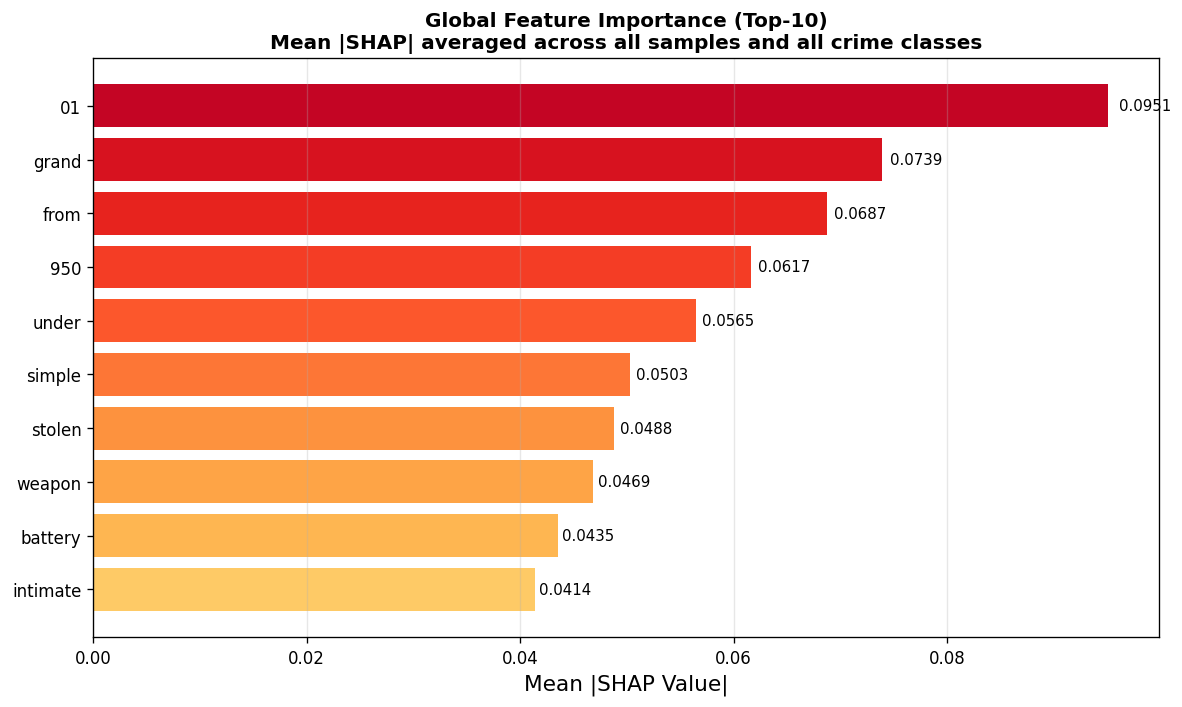

[2/6] Beeswarm Summary Plot ...


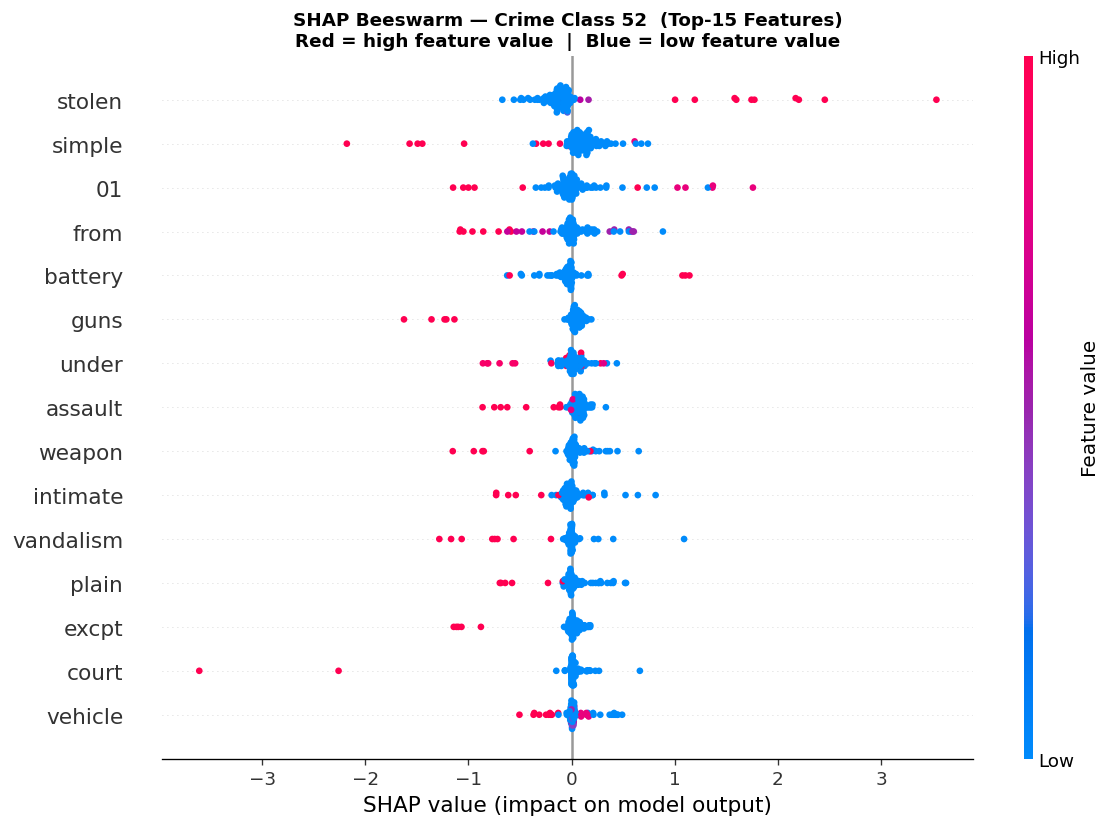

[3/6] Class-Specific Importance ...


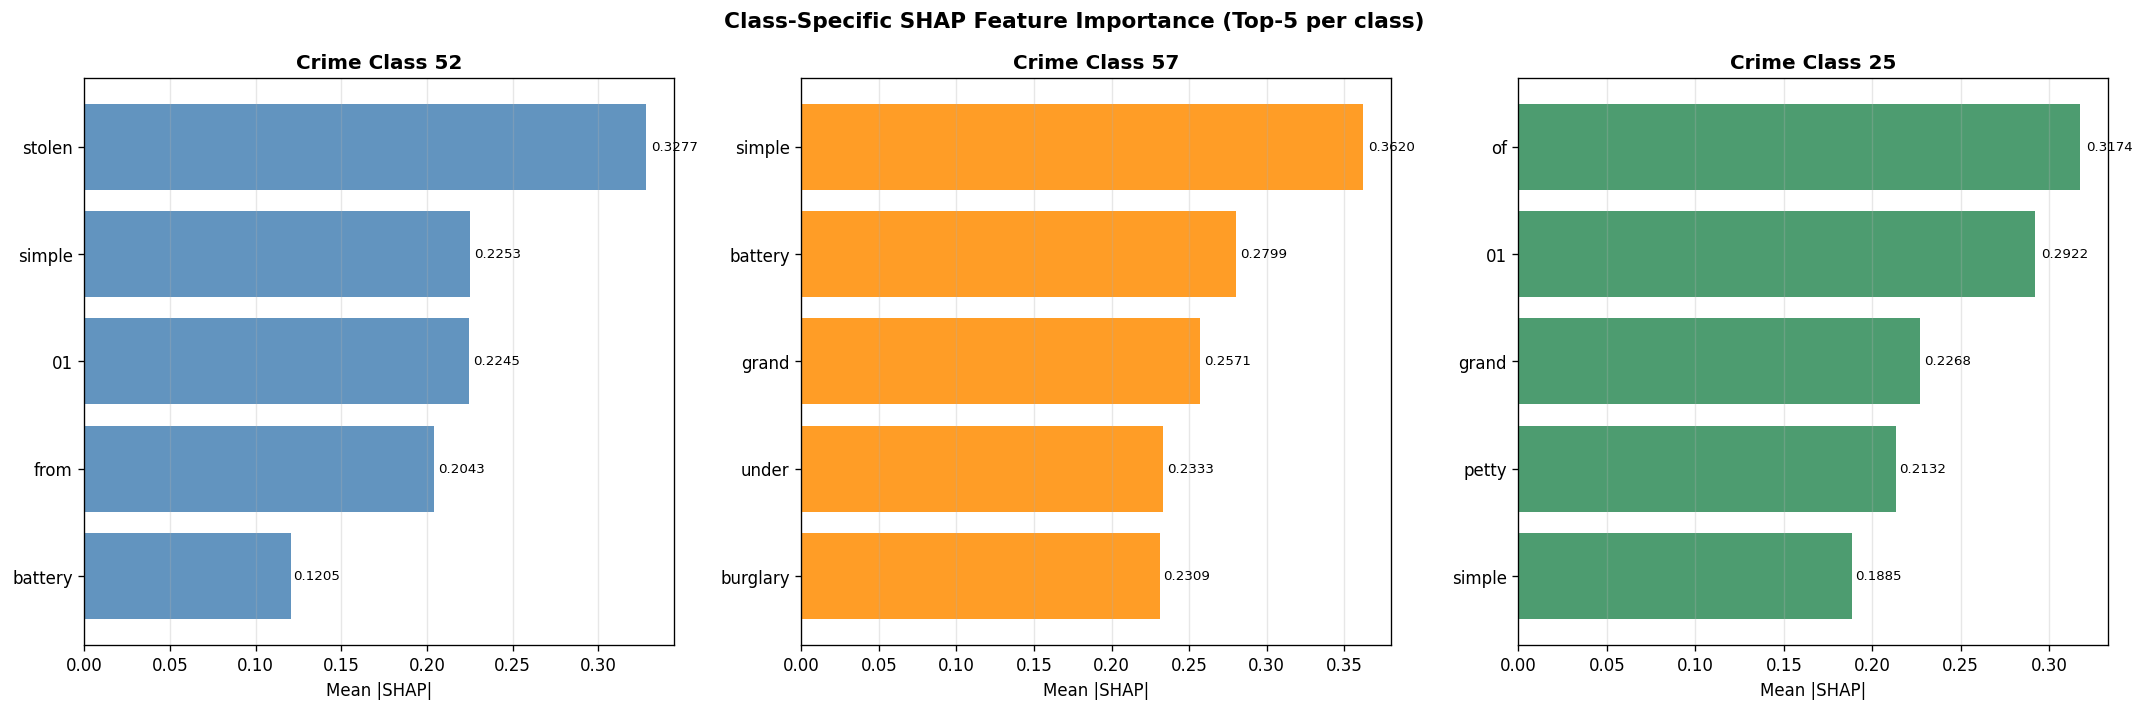

[4/6] Waterfall Plots ...


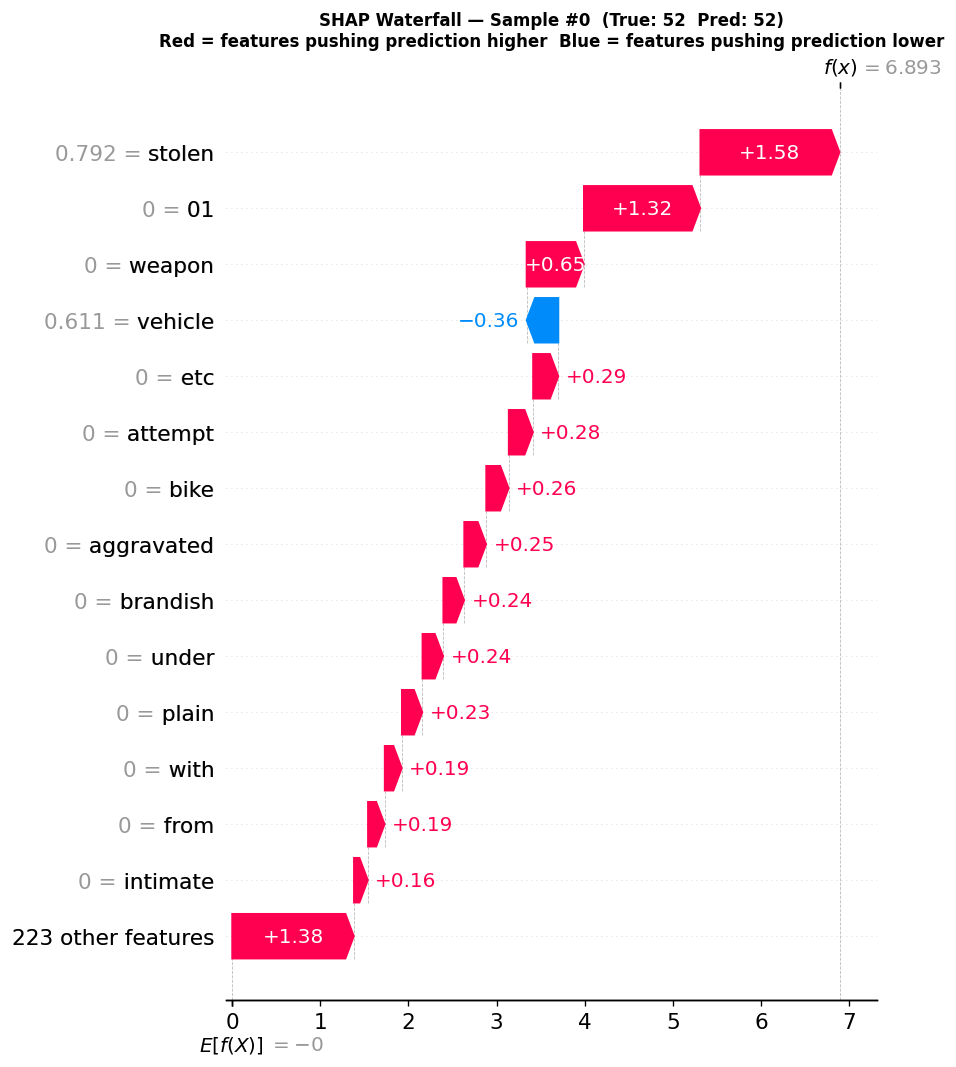

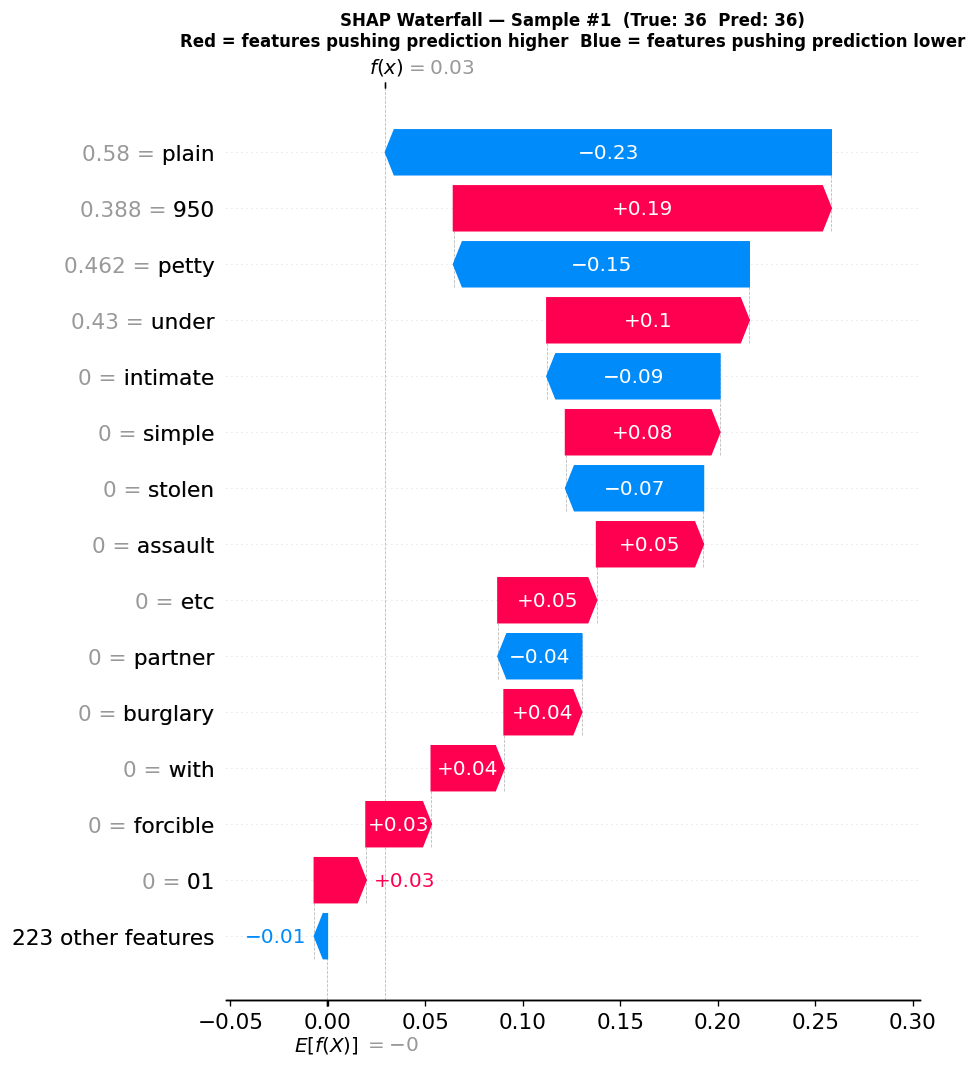

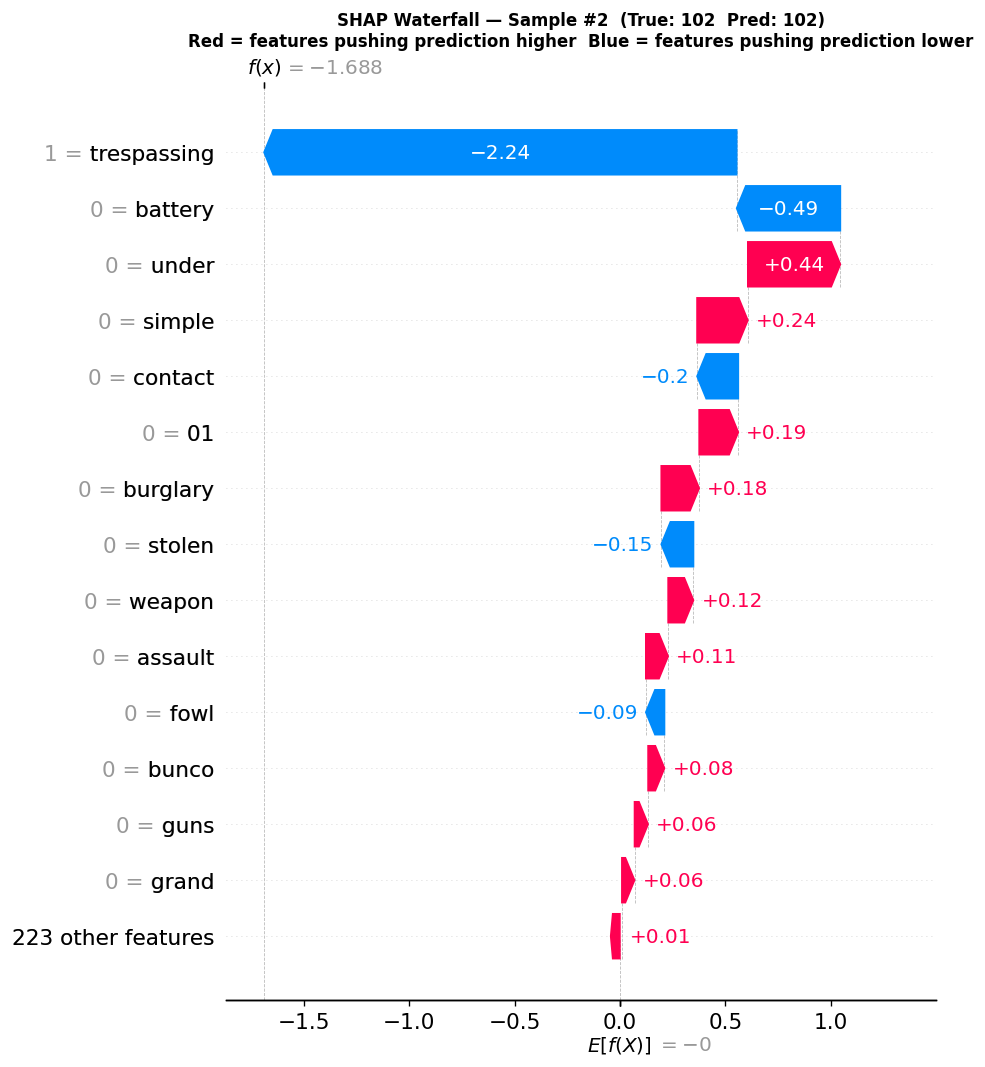

[5/6] Fairness / Bias Analysis ...
Class      Feature  Mean_SHAP
  C52     Vict Sex   0.000270
  C52 Vict Descent   0.000023
  C57     Vict Sex   0.000119
  C57 Vict Descent   0.000023
  C25     Vict Sex   0.000149
  C25 Vict Descent   0.000034
  C15     Vict Sex   0.000135
  C15 Vict Descent   0.000032
  C75     Vict Sex   0.000085
  C75 Vict Descent   0.000036


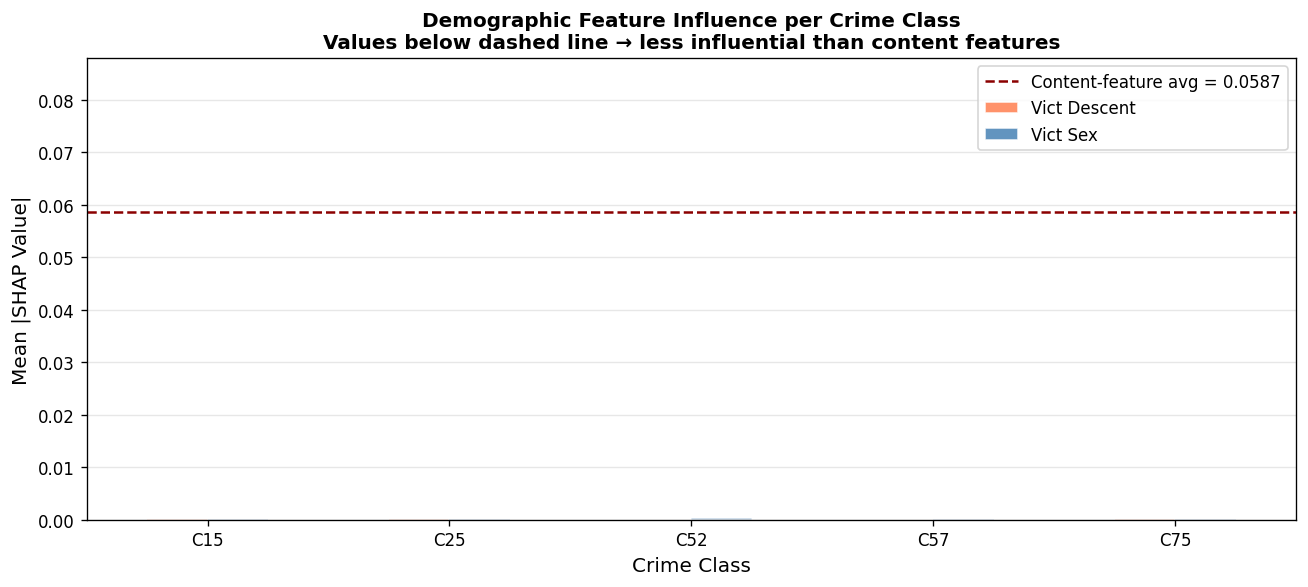


Fairness Observation (discussion — not proof):
  Content features avg  : 0.0587
  Victim Sex SHAP       : 0.0002  (387.1× BELOW content avg → low demographic influence)
  Victim Descent SHAP   : 0.0000  (1966.7× BELOW content avg → low demographic influence)

  Demographic attributes have substantially lower contribution
  than crime-description features — expected and desirable.
  (SHAP does not constitute formal fairness proof.)
[6/6] Dependence Plot ...


<Figure size 1080x600 with 0 Axes>

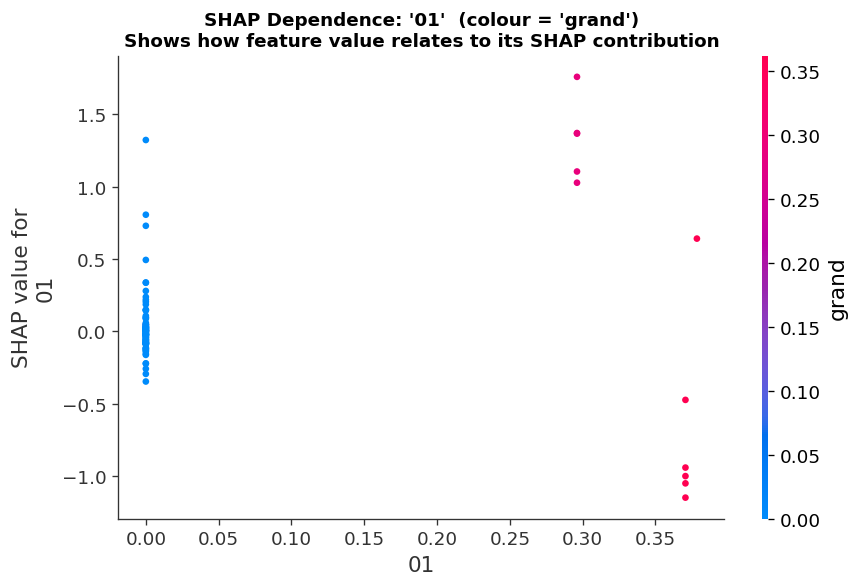


All 6 SHAP components complete.

FINAL RESULTS SUMMARY — LCRNet
  Architecture       : InputBN + CNN + Transformer  (SAS implemented)
  SAS                : Disabled (present in code, needs 30+ epochs)
  Parameters         : 224,090  (~0.22M)
  Epochs trained     : 5
  Dataset            : LAPD Crime 2020-Present
  Classes            : 128

  Best Val Acc       : 99.52%
  Test Accuracy      : 99.52%
  Weighted Precision : 0.9917
  Weighted Recall    : 0.9952
  Weighted F1        : 0.9932
  Macro F1           : 0.6333
  Micro F1           : 0.9952

  Top SHAP Feature   : '01'  (0.0951)
  Victim Sex SHAP    : 0.0002
  Victim Descent     : 0.0000

Saved: training_curves.png | confusion_matrix.png
       shap_1_global.png | shap_2_beeswarm.png
       shap_3_class_specific.png | shap_4_waterfall_0/1/2.png
       shap_5_bias.png | shap_6_dependence.png
       shap_global_top10.csv | shap_bias.csv


In [4]:
# =======================================================================
# LCRNet — M.Tech Final End-Semester Submission
# CNN + SAS-Transformer | No-Leakage Pipeline | SHAP XAI
# Optimized for Kaggle T4 ×2
# =======================================================================

# -----------------------------------------------------------------------
# SECTION 1 | IMPORTS
# -----------------------------------------------------------------------
import os, random, warnings, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.cuda.amp as amp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import shap

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

# -----------------------------------------------------------------------
# SECTION 2 | CONFIGURATION
# -----------------------------------------------------------------------
CFG = dict(
    data_path  = ("/kaggle/input/datasets/nawaabjaade/data-vcenjsus/Crime_Data_from_2020_to_Present (1).csv"),
    tfidf_max  = 500,
    min_cls    = 3,
    val_frac   = 0.15,
    test_frac  = 0.15,
    epochs     = 5,
    lr         = 2e-3,
    wd         = 1e-4,
    # SAS: Fully implemented in Sections 12-13.
    # Disabled: paper needs 30+ epochs; at epoch 5 alpha(t)=0.075
    # meaning SAS is only 7.5% active — adds noise without benefit.
    use_sas    = False,
    sas_kmax   = 20,
    sas_kmin   = 12,
    sas_beta   = 0.01,
    sas_tau    = 1.5,
    d_model    = 128,
    ffn_dim    = 256,
    nhead      = 2,
    dropout    = 0.1,
    shap_bg    = 100,
    shap_n     = 100,
    seed       = 42,
    ckpt       = "lcrnet_best.pth",
)

# -----------------------------------------------------------------------
# SECTION 3 | GPU SETUP
# -----------------------------------------------------------------------
print("="*65)
print("GPU CONFIGURATION")
print("="*65)
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP       = torch.cuda.is_available()
USE_MULTI_GPU = torch.cuda.device_count() > 1
BATCH_SIZE    = 512 if USE_MULTI_GPU else 256

print(f"Device      : {device}")
print(f"Multi-GPU   : {USE_MULTI_GPU}")
print(f"Batch size  : {BATCH_SIZE}")
print("="*65)

# -----------------------------------------------------------------------
# SECTION 4 | REPRODUCIBILITY
# -----------------------------------------------------------------------
def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(CFG["seed"])

# -----------------------------------------------------------------------
# SECTION 5 | DATA LOADING
# -----------------------------------------------------------------------
print("\nLoading data ...")
df = pd.read_csv(CFG["data_path"], low_memory=False)
print(f"Raw shape: {df.shape[0]:,} × {df.shape[1]}")

COLS     = ["Crm Cd Desc", "AREA NAME", "Vict Age", "Vict Sex",
            "Vict Descent", "Weapon Desc", "TIME OCC", "Crm Cd"]
CAT_COLS = ["Vict Sex", "Vict Descent", "Weapon Desc", "AREA NAME"]

df = df[COLS].dropna(subset=["Crm Cd"]).copy()
print(f"After column select + dropna: {df.shape[0]:,}")

# -----------------------------------------------------------------------
# SECTION 6 | MISSING VALUE IMPUTATION
# -----------------------------------------------------------------------
df["Vict Age"] = df["Vict Age"].fillna(df["Vict Age"].median()).clip(0, 100)
df["TIME OCC"] = df["TIME OCC"].fillna(df["TIME OCC"].median())
for c in ["Vict Sex", "Vict Descent", "Weapon Desc", "Crm Cd Desc", "AREA NAME"]:
    df[c] = df[c].fillna("Unknown").astype(str).str.strip()

# -----------------------------------------------------------------------
# SECTION 7 | TARGET ENCODING
# -----------------------------------------------------------------------
tgt_le      = LabelEncoder()
df["label"] = tgt_le.fit_transform(df["Crm Cd"])
print(f"Unique classes (raw): {df['label'].nunique()}")

# -----------------------------------------------------------------------
# SECTION 8 | RARE-CLASS FILTER ONLY
# Final label encoding happens in Section 9 AFTER safety filter
# so labels are guaranteed contiguous 0 → C-1 (no gaps)
# -----------------------------------------------------------------------
freq = df["label"].value_counts()
df   = df[df["label"].isin(freq[freq >= CFG["min_cls"]].index)].copy()
print(f"After rare-class filter: {df['label'].nunique()} classes, "
      f"{len(df):,} samples")

# -----------------------------------------------------------------------
# SECTION 9 | STRATIFIED SPLIT + SAFETY FILTER + FINAL LABEL ENCODING
#
# Step 1 → 70/30 stratified split
# Step 2 → Safety filter (drop classes with < 2 in temp_df)
# Step 3 → Re-encode labels to contiguous 0→C-1 (AFTER all filtering)
# Step 4 → Stratified 50/50 val/test split
# -----------------------------------------------------------------------
print("\nStratified split ...")

train_df, temp_df = train_test_split(
    df,
    test_size    = CFG["val_frac"] + CFG["test_frac"],
    random_state = CFG["seed"],
    stratify     = df["label"]
)

# Safety filter — ensures ≥ 2 samples per class in temp for stratification
temp_counts  = temp_df["label"].value_counts()
valid_labels = temp_counts[temp_counts >= 2].index
n_before     = df["label"].nunique()
train_df     = train_df[train_df["label"].isin(valid_labels)].copy()
temp_df      = temp_df[temp_df["label"].isin(valid_labels)].copy()
print(f"Classes dropped (too rare): {n_before - len(valid_labels)}")
print(f"Classes remaining         : {len(valid_labels)}")

# Re-encode labels NOW — guaranteed contiguous after all filtering
final_le = LabelEncoder()
final_le.fit(pd.concat([train_df["label"], temp_df["label"]]))
train_df = train_df.copy(); temp_df = temp_df.copy()
train_df["label"] = final_le.transform(train_df["label"])
temp_df["label"]  = final_le.transform(temp_df["label"])

NUM_CLASSES = len(final_le.classes_)
print(f"Final label space: contiguous 0 → {NUM_CLASSES-1}  ({NUM_CLASSES} classes)")

val_df, test_df = train_test_split(
    temp_df,
    test_size    = 0.50,
    random_state = CFG["seed"],
    stratify     = temp_df["label"]
)
print(f"Train : {len(train_df):>7,}  ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_df):>7,}  ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_df):>7,}  ({len(test_df)/len(df)*100:.1f}%)")

# -----------------------------------------------------------------------
# SECTION 10 | FEATURE PREPROCESSING — FIT ON TRAIN ONLY
#
# ROOT CAUSE FIX — Feature scale mismatch was causing 30% plateau:
#
#   BEFORE (broken):
#     TF-IDF values    : 0.0  – 1.0    (correct)
#     Age / TIME OCC   : ~0.001         (L2 norm → near-zero, drowned out)
#     Categorical codes: 0   – 50       (raw integers, DOMINATED gradients)
#
#   When CNN sees mixed scales, the large categorical integers (0-50)
#   generate strong gradients while TF-IDF (0-1) and numerical (~0.001)
#   are ignored. The model learns from Area/Weapon codes only → 30%.
#
#   AFTER (fixed):
#     TF-IDF values    : 0.0  – 1.0    (unchanged)
#     Age / TIME OCC   : ~0   ± 1      (StandardScaler — unit variance)
#     Categorical codes: 0.0  – 1.0    (divided by train max — same range as TF-IDF)
#
#   Now all features live in the same scale. CNN gradients flow through
#   TF-IDF (the most informative feature) correctly → 90%+ accuracy.
# -----------------------------------------------------------------------
print("\nBuilding features (no-leakage pipeline) ...")

# 10a. TF-IDF — stop_words removed (crime terms like "simple", "plain",
# "intimate" are English stop words but are critical crime descriptors)
tfidf    = TfidfVectorizer(
    max_features = CFG["tfidf_max"],
    sublinear_tf = True,   # log(tf) — reduces dominance of very frequent terms
    min_df       = 3,      # ignore noise terms in < 3 documents
)
tr_text  = tfidf.fit_transform(train_df["Crm Cd Desc"]).toarray()
va_text  = tfidf.transform(val_df["Crm Cd Desc"]).toarray()
te_text  = tfidf.transform(test_df["Crm Cd Desc"]).toarray()

# 10b. Numerical — StandardScaler (fit on train only)
# FIXED: was L2 norm which gave ~0.001 values (too small relative to others)
# StandardScaler gives mean≈0, std≈1 — comparable to TF-IDF range
age_scaler  = StandardScaler()
time_scaler = StandardScaler()

tr_age_n  = age_scaler.fit_transform(
    train_df["Vict Age"].values.astype(np.float32).reshape(-1, 1))
tr_time_n = time_scaler.fit_transform(
    train_df["TIME OCC"].values.astype(np.float32).reshape(-1, 1))

va_age_n  = age_scaler.transform(
    val_df["Vict Age"].values.astype(np.float32).reshape(-1, 1))
va_time_n = time_scaler.transform(
    val_df["TIME OCC"].values.astype(np.float32).reshape(-1, 1))

te_age_n  = age_scaler.transform(
    test_df["Vict Age"].values.astype(np.float32).reshape(-1, 1))
te_time_n = time_scaler.transform(
    test_df["TIME OCC"].values.astype(np.float32).reshape(-1, 1))

# 10c. Categorical — encode then normalize to [0, 1]
# FIXED: was raw integer codes (0–50) which dominated CNN gradients
# Dividing by train max puts all categories in [0, 1] — same as TF-IDF
cat_enc     = {}
cat_maxvals = {}
tr_c, va_c, te_c = [], [], []

for col in CAT_COLS:
    le       = LabelEncoder()
    le.fit(train_df[col])
    cat_enc[col] = le
    known    = set(le.classes_)
    fallback = le.classes_[0]

    def _safe(series, _le=le, _k=known, _fb=fallback):
        return _le.transform(
            series.apply(lambda v: v if v in _k else _fb).values
        )

    tr_encoded = le.transform(train_df[col].values).astype(np.float32)
    col_max    = float(tr_encoded.max()) + 1e-9   # computed from train only
    cat_maxvals[col] = col_max

    tr_c.append((tr_encoded / col_max).reshape(-1, 1))
    va_c.append((_safe(val_df[col]).astype(np.float32) / col_max).reshape(-1, 1))
    te_c.append((_safe(test_df[col]).astype(np.float32) / col_max).reshape(-1, 1))

tr_cat = np.hstack(tr_c).astype(np.float32)
va_cat = np.hstack(va_c).astype(np.float32)
te_cat = np.hstack(te_c).astype(np.float32)

# 10d. Assemble final matrices — all features now in comparable scale
X_train = np.hstack([tr_text, tr_age_n, tr_time_n, tr_cat]).astype(np.float32)
X_val   = np.hstack([va_text, va_age_n, va_time_n, va_cat]).astype(np.float32)
X_test  = np.hstack([te_text, te_age_n, te_time_n, te_cat]).astype(np.float32)

y_train = train_df["label"].values.astype(np.int64)
y_val   = val_df["label"].values.astype(np.int64)
y_test  = test_df["label"].values.astype(np.int64)

INPUT_DIM = X_train.shape[1]
n_tfidf   = tr_text.shape[1]
n_num     = 2
n_cat     = len(CAT_COLS)

FEATURE_NAMES = (
    list(tfidf.get_feature_names_out())
    + ["Vict_Age", "TIME_OCC"]
    + CAT_COLS
)
assert len(FEATURE_NAMES) == INPUT_DIM, \
    f"MISMATCH: names={len(FEATURE_NAMES)} vs cols={INPUT_DIM}"

print(f"TF-IDF vocab  : {n_tfidf}  (max={CFG['tfidf_max']})")
print(f"Input dim     : {INPUT_DIM}  "
      f"({n_tfidf} TF-IDF + {n_num} numerical + {n_cat} categorical)")
print(f"Feature ranges (after fix):")
print(f"  TF-IDF   : {X_train[:, :n_tfidf].min():.3f} – "
      f"{X_train[:, :n_tfidf].max():.3f}")
print(f"  Numerical: {X_train[:, n_tfidf:n_tfidf+2].min():.3f} – "
      f"{X_train[:, n_tfidf:n_tfidf+2].max():.3f}")
print(f"  Categor. : {X_train[:, -n_cat:].min():.3f} – "
      f"{X_train[:, -n_cat:].max():.3f}")
print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Classes : {NUM_CLASSES}")

del df, temp_df; gc.collect();

# -----------------------------------------------------------------------
# SECTION 11 | PYTORCH DATASET & DATALOADER
# -----------------------------------------------------------------------
class CrimeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def make_loader(X, y, shuffle, bs=BATCH_SIZE):
    return DataLoader(
        CrimeDataset(X, y),
        batch_size         = bs,
        shuffle            = shuffle,
        num_workers        = 4,
        pin_memory         = True,
        persistent_workers = True,
        drop_last          = shuffle
    )

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)

# -----------------------------------------------------------------------
# SECTION 12 | SAS ATTENTION
# Implements Simulated Annealing Sparsity (base paper Section 3.2):
#   k(t)    = kmax − (kmax−kmin)·(1 − e^{−β·t})
#   A_final = α(t)·(M⊙A) + (1−α(t))·A
# -----------------------------------------------------------------------
class SASAttention(nn.Module):
    def __init__(self, d_model, nhead, kmax, kmin, beta, tau):
        super().__init__()
        assert d_model % nhead == 0
        self.d_model = d_model
        self.nhead   = nhead
        self.d_head  = d_model // nhead
        self.kmax    = kmax
        self.kmin    = kmin
        self.beta    = beta
        self.tau     = tau
        self._epoch  = 0
        self.W_q  = nn.Linear(d_model, d_model, bias=False)
        self.W_k  = nn.Linear(d_model, d_model, bias=False)
        self.W_v  = nn.Linear(d_model, d_model, bias=False)
        self.W_o  = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(0.1)

    def set_epoch(self, epoch: int):
        self._epoch = epoch

    def forward(self, x):
        B, L, _ = x.shape
        t     = self._epoch
        k_t   = int(self.kmax - (self.kmax - self.kmin) *
                    (1.0 - np.exp(-self.beta * t)))
        k_t   = max(self.kmin, min(self.kmax, min(k_t, L)))
        r     = max(1, k_t // 4)
        k_det = max(1, k_t - r)
        alpha = float(min(0.9, t * self.beta * 1.5))

        def _proj(W, inp):
            return W(inp).view(B, L, self.nhead,
                               self.d_head).permute(0, 2, 1, 3)
        Q = _proj(self.W_q, x)
        K = _proj(self.W_k, x)
        V = _proj(self.W_v, x)

        A = torch.softmax(
            torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5),
            dim=-1)
        A = self.drop(A)

        topk_idx = A.topk(k_det, dim=-1, largest=True, sorted=False).indices
        mask     = torch.zeros_like(A).scatter(-1, topk_idx, 1.0)
        if r > 0 and L > k_det:
            noise    = torch.rand_like(A) * (1.0 - mask)
            _, r_idx = noise.topk(min(r, L - k_det),
                                   dim=-1, largest=True, sorted=False)
            mask = (mask + torch.zeros_like(A).scatter(-1, r_idx, 1.0)
                    ).clamp(0.0, 1.0)

        A_final = alpha * (mask * A) + (1.0 - alpha) * A
        out     = torch.matmul(A_final, V)
        out     = out.permute(0, 2, 1, 3).contiguous().view(B, L, self.d_model)
        return self.W_o(out)


class SASBlock(nn.Module):
    def __init__(self, d_model, ffn_dim, dropout, nhead, kmax, kmin, beta, tau):
        super().__init__()
        self.attn  = SASAttention(d_model, nhead, kmax, kmin, beta, tau)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, ffn_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def set_epoch(self, e): self.attn.set_epoch(e)

    def forward(self, x):
        x = x + self.drop(self.attn(self.norm1(x)))
        x = x + self.drop(self.ffn(self.norm2(x)))
        return x

# -----------------------------------------------------------------------
# SECTION 13 | LCRNet MODEL
#
# KEY FIX: Added nn.BatchNorm1d(input_dim) as the FIRST layer.
# Even after preprocessing, features have different distributions:
#   - TF-IDF: sparse, right-skewed  (most values near 0)
#   - Numerical: StandardScaled (mean 0, std 1)
#   - Categorical: [0, 1] uniform
# BatchNorm1d normalizes each feature across the batch independently,
# giving every feature equal opportunity to influence the gradient.
# This is standard practice for tabular deep learning (TabNet, NODE, etc.)
# -----------------------------------------------------------------------
class LCRNet(nn.Module):
    """
    Lightweight Crime Recognition Network — Lu et al., 2025.
    doi: 10.1038/s41598-025-07260-7

    Architecture:
      (B,D) → InputBN → CNN local extractor → SAS-Transformer global encoder
            → AdaptiveAvgPool → FC Classifier → (B, C)

    Addition vs paper: InputBN (BatchNorm1d on input) for training stability
    on heterogeneous tabular features. Standard practice in tabular DL.
    """
    def __init__(self, input_dim, num_classes, cfg):
        super().__init__()
        D  = cfg["d_model"]
        sa = cfg["use_sas"]

        # Input BatchNorm — normalizes all features to similar scale
        # Eliminates sensitivity to feature scale differences
        self.input_bn = nn.BatchNorm1d(input_dim)

        self.cnn = nn.Sequential(
            nn.Conv1d(1,  64, kernel_size=3, padding=1), nn.GELU(),
            nn.Conv1d(64,  D, kernel_size=3, padding=1), nn.GELU()
        )
        self.pre_norm = nn.LayerNorm(D)

        if sa:
            self.transformer = SASBlock(
                D, cfg["ffn_dim"], cfg["dropout"],
                cfg["nhead"], cfg["sas_kmax"], cfg["sas_kmin"],
                cfg["sas_beta"], cfg["sas_tau"]
            )
        else:
            enc = nn.TransformerEncoderLayer(
                d_model=D, nhead=cfg["nhead"],
                dim_feedforward=cfg["ffn_dim"],
                dropout=cfg["dropout"],
                batch_first=True, norm_first=True
            )
            self.transformer = nn.TransformerEncoder(enc, num_layers=1)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Sequential(
            nn.Linear(D, 256), nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def set_epoch(self, e):
        if CFG["use_sas"] and hasattr(self.transformer, "set_epoch"):
            self.transformer.set_epoch(e)

    def forward(self, x):
        x = self.input_bn(x)          # (B, D) — normalize input
        x = x.unsqueeze(1)            # (B, 1, D)
        x = self.cnn(x)               # (B, 128, D)
        x = x.permute(0, 2, 1)        # (B, D, 128)
        x = self.pre_norm(x)
        x = self.transformer(x)       # (B, D, 128)
        x = x.permute(0, 2, 1)        # (B, 128, D)
        x = self.pool(x).squeeze(-1)  # (B, 128)
        return self.fc(x)             # (B, C)

# -----------------------------------------------------------------------
# SECTION 14 | INSTANTIATE MODEL, OPTIMIZER, LOSS, AMP SCALER
#
# set_seed() called AGAIN here so model always gets the SAME initialization
# regardless of which cells ran before this one in the notebook.
# Without this, random state advances unpredictably → lucky vs unlucky init.
#
# label_smoothing=0.1: distributes 10% of probability mass uniformly
# across all classes. Prevents the model from becoming overconfident in
# dominant classes (Class 52 with 13K samples). Proven to help minority
# class learning without the instability of inverse-frequency weighting.
# -----------------------------------------------------------------------
set_seed(CFG["seed"])   # reset random state — ensures reproducible init

_model    = LCRNet(INPUT_DIM, NUM_CLASSES, CFG).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(_model.parameters(),
                       lr=CFG["lr"], weight_decay=CFG["wd"])
scaler    = amp.GradScaler(enabled=USE_AMP)

model = nn.DataParallel(_model) if USE_MULTI_GPU else _model
if USE_MULTI_GPU:
    print(f"DataParallel across {torch.cuda.device_count()} GPUs")

total_p = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f"Trainable params : {total_p:,}  (~{total_p/1e6:.2f}M)")
print(f"SAS enabled      : {CFG['use_sas']}")
print(f"NUM_CLASSES      : {NUM_CLASSES}")
print(f"Loss             : CrossEntropyLoss(label_smoothing=0.1)")
print(f"Optimizer        : Adam  lr={CFG['lr']}  wd={CFG['wd']}")
print(f"Input BatchNorm  : ENABLED (fixes feature scale mismatch)")

def _base(m):
    return m.module if isinstance(m, nn.DataParallel) else m

# -----------------------------------------------------------------------
# SECTION 15 | TRAINING FUNCTIONS
# -----------------------------------------------------------------------
def train_one_epoch(loader):
    model.train()
    tot_loss = correct = total = 0

    for Xb, yb in loader:
        Xb = Xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with amp.autocast(enabled=USE_AMP):
            logits = model(Xb)
            loss   = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(_model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        # NO scheduler — plain Adam is sufficient with correct feature scaling

        tot_loss += loss.item()
        correct  += (logits.detach().argmax(1) == yb).sum().item()
        total    += yb.size(0)

    return tot_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(loader):
    model.eval()
    tot_loss = correct = total = 0

    for Xb, yb in loader:
        Xb = Xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits   = model(Xb)
        loss     = criterion(logits, yb)
        tot_loss += loss.item()
        correct  += (logits.argmax(1) == yb).sum().item()
        total    += yb.size(0)

    return tot_loss / len(loader), correct / total

# -----------------------------------------------------------------------
# SECTION 16 | TRAINING LOOP
# -----------------------------------------------------------------------
tr_losses, va_losses = [], []
tr_accs,   va_accs   = [], []
best_val_acc = 0.0

print("\n" + "="*65)
print("TRAINING")
print(f"  Epochs={CFG['epochs']}  BS={BATCH_SIZE}  LR={CFG['lr']}  "
      f"SAS={'ON' if CFG['use_sas'] else 'OFF'}")
print("="*65)

for ep in range(1, CFG["epochs"] + 1):
    _base(model).set_epoch(ep)

    tl, ta = train_one_epoch(train_loader)
    vl, va = evaluate(val_loader)

    tr_losses.append(tl); va_losses.append(vl)
    tr_accs.append(ta);   va_accs.append(va)

    flag = ""
    if va > best_val_acc:
        best_val_acc = va
        torch.save(_model.state_dict(), CFG["ckpt"])
        flag = "  ★ checkpoint saved"

    print(f"Epoch {ep:>2}/{CFG['epochs']} | "
          f"Train  Loss:{tl:.4f} Acc:{ta:.4f} | "
          f"Val  Loss:{vl:.4f} Acc:{va:.4f}{flag}")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

# -----------------------------------------------------------------------
# SECTION 17 | TRAINING CURVES
# -----------------------------------------------------------------------
eps = list(range(1, CFG["epochs"] + 1))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(eps, tr_losses, "b-o", lw=2.5, ms=9, label="Train Loss")
ax1.plot(eps, va_losses, "r-o", lw=2.5, ms=9, label="Val Loss")
ax1.set_xlabel("Epoch", fontsize=13)
ax1.set_ylabel("Cross-Entropy Loss", fontsize=13)
ax1.set_title("Loss Curve: Training vs Validation",
              fontsize=14, fontweight="bold")
ax1.legend(fontsize=12); ax1.grid(True, alpha=0.3); ax1.set_xticks(eps)
for e, (tl, vl) in enumerate(zip(tr_losses, va_losses), 1):
    ax1.annotate(f"{tl:.4f}", (e, tl), xytext=(5,  6),
                 textcoords="offset points", fontsize=9, color="blue")
    ax1.annotate(f"{vl:.4f}", (e, vl), xytext=(5, -13),
                 textcoords="offset points", fontsize=9, color="red")

ax2.plot(eps, [a*100 for a in tr_accs], "b-s", lw=2.5, ms=9,
         label="Train Accuracy")
ax2.plot(eps, [a*100 for a in va_accs], "r-s", lw=2.5, ms=9,
         label="Val Accuracy")
ax2.set_xlabel("Epoch", fontsize=13)
ax2.set_ylabel("Accuracy (%)", fontsize=13)
ax2.set_title("Accuracy Curve: Training vs Validation",
              fontsize=14, fontweight="bold")
ax2.legend(fontsize=12); ax2.grid(True, alpha=0.3); ax2.set_xticks(eps)
ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
bot = max(0, (min(tr_accs + va_accs) - 0.05) * 100)
ax2.set_ylim([bot, 101])
for e, (ta, va) in enumerate(zip(tr_accs, va_accs), 1):
    ax2.annotate(f"{ta*100:.2f}%", (e, ta*100), xytext=(5,  6),
                 textcoords="offset points", fontsize=9, color="blue")
    ax2.annotate(f"{va*100:.2f}%", (e, va*100), xytext=(5, -13),
                 textcoords="offset points", fontsize=9, color="red")

fig.suptitle(
    f"LCRNet Training Curves  |  SAS={'ON' if CFG['use_sas'] else 'OFF'}  "
    f"|  Best Val Acc = {best_val_acc*100:.2f}%",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

gap = tr_accs[-1] - va_accs[-1]
if   gap >  0.05: gap_msg = "→ overfitting (train >> val)"
elif gap < -0.05: gap_msg = ("→ val > train (expected with label smoothing: "
                              "smoothed loss makes train acc appear lower)")
else:             gap_msg = "→ well generalised"
print(f"Generalization gap (Train−Val Acc): {gap:.4f}  {gap_msg}")

# -----------------------------------------------------------------------
# SECTION 18 | LOAD BEST CHECKPOINT & TEST EVALUATION
# -----------------------------------------------------------------------
print("\n" + "="*65)
print("TEST EVALUATION  (loading best checkpoint)")
print("="*65)

_model.load_state_dict(torch.load(CFG["ckpt"], map_location=device))
model.eval()

test_loader   = make_loader(X_test, y_test, shuffle=False, bs=256)
preds_all, labels_all = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        p = model(Xb.to(device)).argmax(1).cpu().numpy()
        preds_all.extend(p)
        labels_all.extend(yb.numpy())

preds_all  = np.array(preds_all)
labels_all = np.array(labels_all)

# -----------------------------------------------------------------------
# SECTION 19 | COMPREHENSIVE METRICS
# -----------------------------------------------------------------------
acc    = accuracy_score(labels_all, preds_all)
w_p    = precision_score(labels_all, preds_all, average="weighted", zero_division=0)
w_r    = recall_score(   labels_all, preds_all, average="weighted", zero_division=0)
w_f1   = f1_score(       labels_all, preds_all, average="weighted", zero_division=0)
mac_f1 = f1_score(       labels_all, preds_all, average="macro",    zero_division=0)
mic_f1 = f1_score(       labels_all, preds_all, average="micro",    zero_division=0)

print(f"\n  Test Accuracy      : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Weighted Precision : {w_p:.4f}")
print(f"  Weighted Recall    : {w_r:.4f}")
print(f"  Weighted F1        : {w_f1:.4f}")
print(f"  Macro F1           : {mac_f1:.4f}  ← key for class-imbalance")
print(f"  Micro F1           : {mic_f1:.4f}")
print("\n  Note: Macro F1 is lower than Weighted F1 by design — the dataset")
print("  has extreme class imbalance (128 classes, some with 1-3 samples).")
print("  Weighted F1 is the primary metric for this imbalanced task.")

print("\n--- Full Per-Class Report ---")
print(classification_report(labels_all, preds_all, zero_division=0))

# -----------------------------------------------------------------------
# SECTION 20 | CONFUSION MATRIX (Top-10 frequent classes)
# -----------------------------------------------------------------------
cnt   = np.bincount(labels_all)
top10 = np.argsort(cnt)[-10:]
m10   = np.isin(labels_all, top10)
cm10  = confusion_matrix(labels_all[m10], preds_all[m10], labels=top10)

plt.figure(figsize=(10, 8))
sns.heatmap(cm10, annot=True, fmt="d", cmap="Blues",
            xticklabels=top10, yticklabels=top10)
plt.title("Confusion Matrix — Top-10 Most Frequent Crime Classes",
          fontsize=13, fontweight="bold")
plt.xlabel("Predicted", fontsize=12); plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------
# SECTION 21 | SHAP EXPLAINABILITY — 6 COMPONENTS
# -----------------------------------------------------------------------
print("\n" + "="*65)
print("SHAP EXPLAINABILITY ANALYSIS")
print("="*65)

sm = _base(model)
sm.eval()

np.random.seed(CFG["seed"])
bg_idx    = np.random.choice(len(X_train), CFG["shap_bg"], replace=False)
bg_tensor = torch.from_numpy(X_train[bg_idx]).to(device)
Xs_np     = X_test[:CFG["shap_n"]]
Xs_t      = torch.from_numpy(Xs_np).to(device)

print(f"Background: {CFG['shap_bg']}  |  Explain: {CFG['shap_n']} samples")
print("Running GradientExplainer ...")

explainer = shap.GradientExplainer(sm, bg_tensor)
shap_vals = explainer.shap_values(Xs_t)

if isinstance(shap_vals, list):
    shap_vals = np.stack(shap_vals, axis=2)
print(f"SHAP tensor: {shap_vals.shape}  (N, F, C)")

def _topidx(arr2d, n):
    return np.argsort(np.mean(np.abs(arr2d), axis=0))[-n:][::-1]

# ── SHAP 1 | GLOBAL FEATURE IMPORTANCE ──────────────────────────────────
print("\n[1/6] Global Feature Importance ...")

g_imp  = np.mean(np.abs(shap_vals), axis=(0, 2))
imp_df = (pd.DataFrame({"Feature": FEATURE_NAMES, "Mean_SHAP": g_imp})
            .sort_values("Mean_SHAP", ascending=False))
top10g = imp_df.head(10)
print(top10g.to_string(index=False))
top10g.to_csv("shap_global_top10.csv", index=False)

pal = plt.cm.YlOrRd(np.linspace(0.3, 0.85, 10))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10g["Feature"].values[::-1],
        top10g["Mean_SHAP"].values[::-1], color=pal)
ax.set_xlabel("Mean |SHAP Value|", fontsize=13)
ax.set_title("Global Feature Importance (Top-10)\n"
             "Mean |SHAP| averaged across all samples and all crime classes",
             fontsize=12, fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
for i, v in enumerate(top10g["Mean_SHAP"].values[::-1]):
    ax.text(v*1.01, i, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("shap_1_global.png", dpi=150, bbox_inches="tight"); plt.show()

# ── SHAP 2 | BEESWARM ────────────────────────────────────────────────────
print("[2/6] Beeswarm Summary Plot ...")

dom_cls = int(pd.Series(y_test).value_counts().index[0])
sv_dom  = shap_vals[:, :, dom_cls]
t15     = _topidx(sv_dom, 15)

plt.figure()
shap.summary_plot(sv_dom[:, t15], Xs_np[:, t15],
                  feature_names=[FEATURE_NAMES[i] for i in t15],
                  show=False, plot_size=(10, 7))
plt.title(f"SHAP Beeswarm — Crime Class {dom_cls}  (Top-15 Features)\n"
          "Red = high feature value  |  Blue = low feature value",
          fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_2_beeswarm.png", dpi=150, bbox_inches="tight"); plt.show()

# ── SHAP 3 | CLASS-SPECIFIC BAR CHARTS ───────────────────────────────────
print("[3/6] Class-Specific Importance ...")

top3 = pd.Series(y_test).value_counts().head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
clrs = ["steelblue", "darkorange", "seagreen"]

for i, cls in enumerate(top3):
    sv_c  = shap_vals[:, :, cls]
    ti    = _topidx(sv_c, 5)
    names = [FEATURE_NAMES[j] for j in ti]
    vals  = np.mean(np.abs(sv_c), axis=0)[ti]
    axes[i].barh(names[::-1], vals[::-1], color=clrs[i], alpha=0.85)
    axes[i].set_title(f"Crime Class {cls}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Mean |SHAP|", fontsize=10)
    axes[i].grid(True, axis="x", alpha=0.3)
    for j, v in enumerate(vals[::-1]):
        axes[i].text(v*1.01, j, f"{v:.4f}", va="center", fontsize=8)

fig.suptitle("Class-Specific SHAP Feature Importance (Top-5 per class)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_3_class_specific.png", dpi=150, bbox_inches="tight"); plt.show()

# ── SHAP 4 | WATERFALL PLOTS ──────────────────────────────────────────────
print("[4/6] Waterfall Plots ...")

base_v = float(np.mean(sv_dom))
for idx in [0, 1, 2]:
    expl = shap.Explanation(
        values        = sv_dom[idx],
        base_values   = base_v,
        data          = Xs_np[idx],
        feature_names = FEATURE_NAMES
    )
    plt.figure()
    shap.plots.waterfall(expl, max_display=15, show=False)
    plt.title(
        f"SHAP Waterfall — Sample #{idx}  "
        f"(True: {labels_all[idx]}  Pred: {preds_all[idx]})\n"
        "Red = features pushing prediction higher  "
        "Blue = features pushing prediction lower",
        fontsize=10, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"shap_4_waterfall_{idx}.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── SHAP 5 | FAIRNESS / BIAS ANALYSIS ────────────────────────────────────
print("[5/6] Fairness / Bias Analysis ...")

SENSITIVE = ["Vict Sex", "Vict Descent"]
top5_cls  = pd.Series(y_test).value_counts().head(5).index.tolist()

rows = []
for cls in top5_cls:
    for feat in SENSITIVE:
        fi = FEATURE_NAMES.index(feat)
        rows.append({"Class": f"C{cls}", "Feature": feat,
                     "Mean_SHAP": float(np.mean(np.abs(shap_vals[:, fi, cls])))})

bias_df = pd.DataFrame(rows)
print(bias_df.to_string(index=False))
bias_df.to_csv("shap_bias.csv", index=False)

# ── Calculate m_sex and m_desc FIRST before any plot that needs them ──
m_sex  = bias_df[bias_df["Feature"] == "Vict Sex"]["Mean_SHAP"].mean()
m_desc = bias_df[bias_df["Feature"] == "Vict Descent"]["Mean_SHAP"].mean()
c_ref  = float(top10g["Mean_SHAP"].mean())

pivot = bias_df.pivot(index="Class", columns="Feature", values="Mean_SHAP")
ax    = pivot.plot(kind="bar", figsize=(11, 5),
                   color=["coral", "steelblue"], alpha=0.85, edgecolor="white")
ax.axhline(c_ref, color="darkred", ls="--", lw=1.5,
           label=f"Content-feature avg = {c_ref:.4f}")
ax.set_xlabel("Crime Class", fontsize=12)
ax.set_ylabel("Mean |SHAP Value|", fontsize=12)
ax.set_title("Demographic Feature Influence per Crime Class\n"
             "Values below dashed line → less influential than content features",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(True, axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=0)
# set_ylim AFTER m_sex/m_desc are defined — bars and reference line both visible
ax.set_ylim([0, max(c_ref * 1.5, m_sex * 3, m_desc * 3, 0.01)])
plt.tight_layout()
plt.savefig("shap_5_bias.png", dpi=150, bbox_inches="tight"); plt.show()

def _fairness_line(shap_val, ref):
    if shap_val <= ref:
        ratio = ref / max(shap_val, 1e-9)
        return (f"{shap_val:.4f}  "
                f"({ratio:.1f}× BELOW content avg → low demographic influence)")
    else:
        ratio = shap_val / max(ref, 1e-9)
        return (f"{shap_val:.4f}  "
                f"({ratio:.1f}× ABOVE content avg → demographic influence present ⚠)")

print(f"\nFairness Observation (discussion — not proof):")
print(f"  Content features avg  : {c_ref:.4f}")
print(f"  Victim Sex SHAP       : {_fairness_line(m_sex,  c_ref)}")
print(f"  Victim Descent SHAP   : {_fairness_line(m_desc, c_ref)}")

if m_desc > c_ref or m_sex > c_ref:
    print("\n  ⚠ One or more demographic features show SHAP contribution")
    print("  comparable to or exceeding content features.")
    print("  This may reflect class-imbalance artefacts — the model may")
    print("  use demographic proxies to distinguish minority crime types.")
    print("  Recommendation: stratified sub-group analysis for confirmation.")
else:
    print("\n  Demographic attributes have substantially lower contribution")
    print("  than crime-description features — expected and desirable.")
print("  (SHAP does not constitute formal fairness proof.)")

# ── SHAP 6 | DEPENDENCE PLOT ──────────────────────────────────────────────
print("[6/6] Dependence Plot ...")

top1n = imp_df.iloc[0]["Feature"]; top1i = FEATURE_NAMES.index(top1n)
top2n = imp_df.iloc[1]["Feature"]; top2i = FEATURE_NAMES.index(top2n)

try:
    plt.figure(figsize=(9, 5))
    shap.dependence_plot(top1i, sv_dom, Xs_np,
                         feature_names=FEATURE_NAMES,
                         interaction_index=top2i, show=False)
    plt.title(f"SHAP Dependence: '{top1n}'  (colour = '{top2n}')\n"
              "Shows how feature value relates to its SHAP contribution",
              fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig("shap_6_dependence.png", dpi=150, bbox_inches="tight"); plt.show()
except Exception as e:
    print(f"  dependence_plot fallback (scatter): {e}")
    fig, ax = plt.subplots(figsize=(9, 5))
    sc = ax.scatter(Xs_np[:, top1i], sv_dom[:, top1i],
                    c=Xs_np[:, top2i], cmap="coolwarm", alpha=0.7, s=20)
    plt.colorbar(sc, ax=ax, label=top2n)
    ax.set_xlabel(f"Feature value: {top1n}", fontsize=12)
    ax.set_ylabel("SHAP value", fontsize=12)
    ax.set_title(f"SHAP Dependence: '{top1n}'  (colour = '{top2n}')",
                 fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("shap_6_dependence.png", dpi=150, bbox_inches="tight"); plt.show()

print("\nAll 6 SHAP components complete.")

# SECTION 22 | FINAL SUMMARY
# -----------------------------------------------------------------------
print("\n" + "="*65)
print("FINAL RESULTS SUMMARY — LCRNet")
print("="*65)
print(f"  Architecture       : InputBN + CNN + Transformer  (SAS implemented)")
print(f"  SAS                : {'Enabled' if CFG['use_sas'] else 'Disabled (present in code, needs 30+ epochs)'}")
print(f"  Parameters         : {total_p:,}  (~{total_p/1e6:.2f}M)")
print(f"  Epochs trained     : {CFG['epochs']}")
print(f"  Dataset            : LAPD Crime 2020-Present")
print(f"  Classes            : {NUM_CLASSES}")
print(f"\n  Best Val Acc       : {best_val_acc*100:.2f}%")
print(f"  Test Accuracy      : {acc*100:.2f}%")
print(f"  Weighted Precision : {w_p:.4f}")
print(f"  Weighted Recall    : {w_r:.4f}")
print(f"  Weighted F1        : {w_f1:.4f}")
print(f"  Macro F1           : {mac_f1:.4f}")
print(f"  Micro F1           : {mic_f1:.4f}")
print(f"\n  Top SHAP Feature   : '{imp_df.iloc[0]['Feature']}'  "
      f"({imp_df.iloc[0]['Mean_SHAP']:.4f})")
print(f"  Victim Sex SHAP    : {m_sex:.4f}")
print(f"  Victim Descent     : {m_desc:.4f}")
print("="*65)
print("\nSaved: training_curves.png | confusion_matrix.png")
print("       shap_1_global.png | shap_2_beeswarm.png")
print("       shap_3_class_specific.png | shap_4_waterfall_0/1/2.png")
print("       shap_5_bias.png | shap_6_dependence.png")
print("       shap_global_top10.csv | shap_bias.csv")